In [1]:
import pandas as pd, si_units as si, matplotlib.pyplot as plt, numpy as np, PLOT_SETTINGS as ps, matplotlib.ticker as ticker, ast, os
import feos
from molmass import Formula
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.lines import Line2D
from io import StringIO

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

co2 = Formula("CO2")
n2 = Formula("N2")

In [2]:
def eos_from_kij_helmholtz(kij, parameters):
    """Returns equation of state (PC-SAFT) for current kij."""
    p = feos.Parameters.new_binary(parameters.pure_records, k_ij = kij)
    return feos.HelmholtzEnergyFunctional.pcsaft(p)

def kij(T):
    """
    Calculate k_ij as a function of temperature T.
    """
    return (-0.590685 + 2.742580e-03 * T + 9.584218e-06 * T**2 - 4.629593e-08 * T**3)

RP_Pure_CO2         = pd.read_csv('REFPROP_CO2.csv')
T_RP_Pure_CO2       = RP_Pure_CO2['T_[K]'].values
P_RP_Pure_CO2       = RP_Pure_CO2['Saturation_Pressure_[bar]'].values
IFT_RP_Pure_CO2     = RP_Pure_CO2['IFT_[N/m]'].values

In [3]:
def M_mix(x_co2):
    return x_co2 * co2.mass + (1.0 - x_co2) * n2.mass  # kg/mol

def mass_density(molar_density, M):  # mol/m^3 * kg/mol -> kg/m^3
    return (molar_density * M) / (si.KILO * si.MOL / si.METER**3)

def set_custom_xlabel(ax, fontsize=ps.label_fontsize):
    
    ax.text(0.33, -0.17, r"$x_{\mathrm{CO_2}}$",
        color="blue", fontsize=fontsize,transform=ax.transAxes, ha="right")

    ax.text(0.35, -0.17, r"$,$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="center")

    ax.text(0.36, -0.17, r"$y_{\mathrm{CO_2}}$",
        color="red", fontsize=fontsize,transform=ax.transAxes, ha="left")

    ax.text(0.49, -0.17, r"$/ \;[{\mathrm{mol} \; \mathrm{mol}^{-1}}]$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="left")
    
def save_plot(fig, filename_base, folder="PLOTS"):
    """
    Save a figure as both PNG and PDF using ps.save_figure.
    """
    os.makedirs(folder, exist_ok=True)

    png_path = os.path.join(folder, f"{filename_base}.png")
    pdf_path = os.path.join(folder, f"{filename_base}.pdf")

    ps.save_figure(fig, png_path)
    ps.save_figure(fig, pdf_path)

In [4]:
parameters          = feos.Parameters.from_json(["nitrogen", "carbon dioxide"], "parameters.json")
pts                 = 500
target_pressure     = 20                          # bar
temperatures        = np.arange(220, 281, 10)     # Kelvin
fluid               = 'Nitrogen&CO2'
# kij                 = kij(temperature)
# parameters
temperatures

array([220, 230, 240, 250, 260, 270, 280])

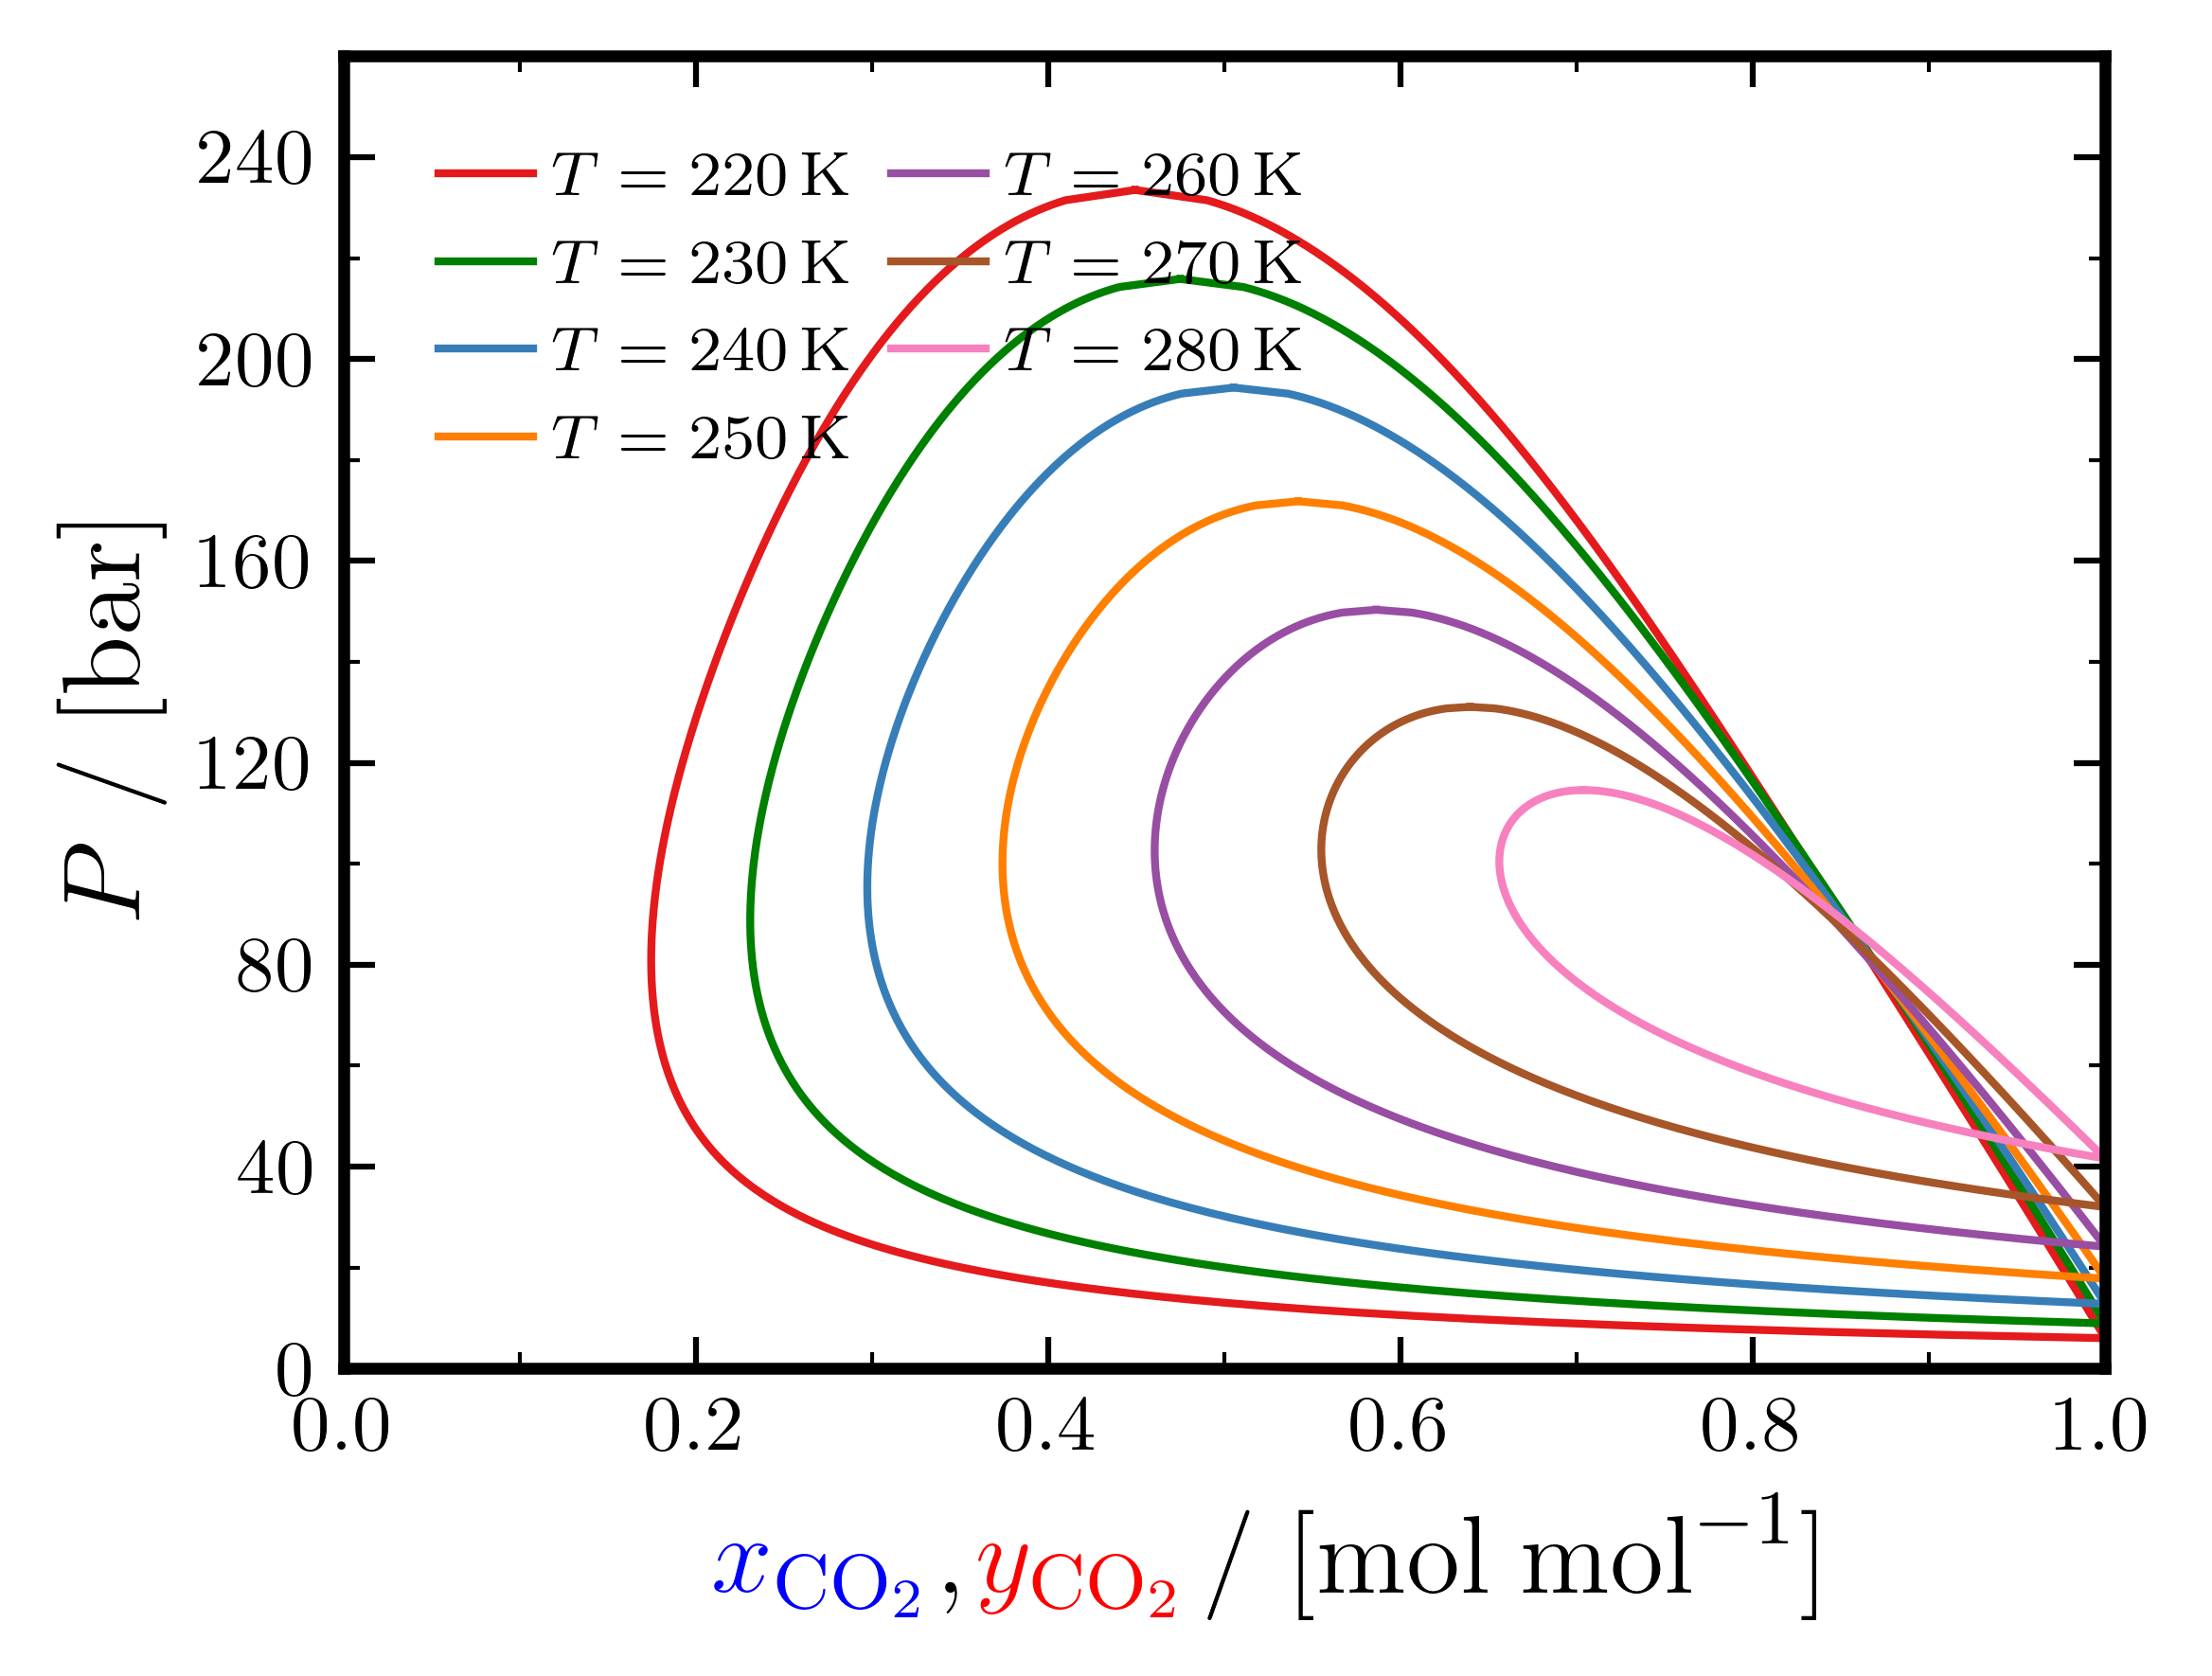

In [5]:
fig, ax = ps.plot_init()

for T, color in zip(temperatures, ps.colors):
    
    kij_T       = kij(T)
    eos         = eos_from_kij_helmholtz(kij_T, parameters)
    dia_kij     = feos.PhaseDiagram.binary_vle(eos,T * si.KELVIN, npoints=pts)
    df_kij      = pd.DataFrame(dia_kij.to_dict(feos.Contributions.Residual))
    
    # Liquid branch
    ax.plot(df_kij["x1"],df_kij["pressure"] * (si.PASCAL / si.BAR),
        color=color,linestyle="-",linewidth=ps.linewidth,label=fr"$T={T:.0f}\,\mathrm{{K}}$")

    # Vapor branch
    ax.plot(df_kij["y1"],df_kij["pressure"] * (si.PASCAL / si.BAR),color=color,
        linestyle="-",linewidth=ps.linewidth)
    
ax.minorticks_on()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))

set_custom_xlabel(ax, fontsize=ps.label_fontsize)
ax.set_ylabel(r'$P \; / \; [\mathrm{bar}]$', fontsize=ps.label_fontsize)
ax.set_xlabel("")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 260)

ps.style_legend(ax,loc='upper left',ncol=2,borderaxespad=1.0,frame=False)

plt.show()
save_plot(fig, f'PX_DIAGRAM_comp_{fluid}_multiT_kij')

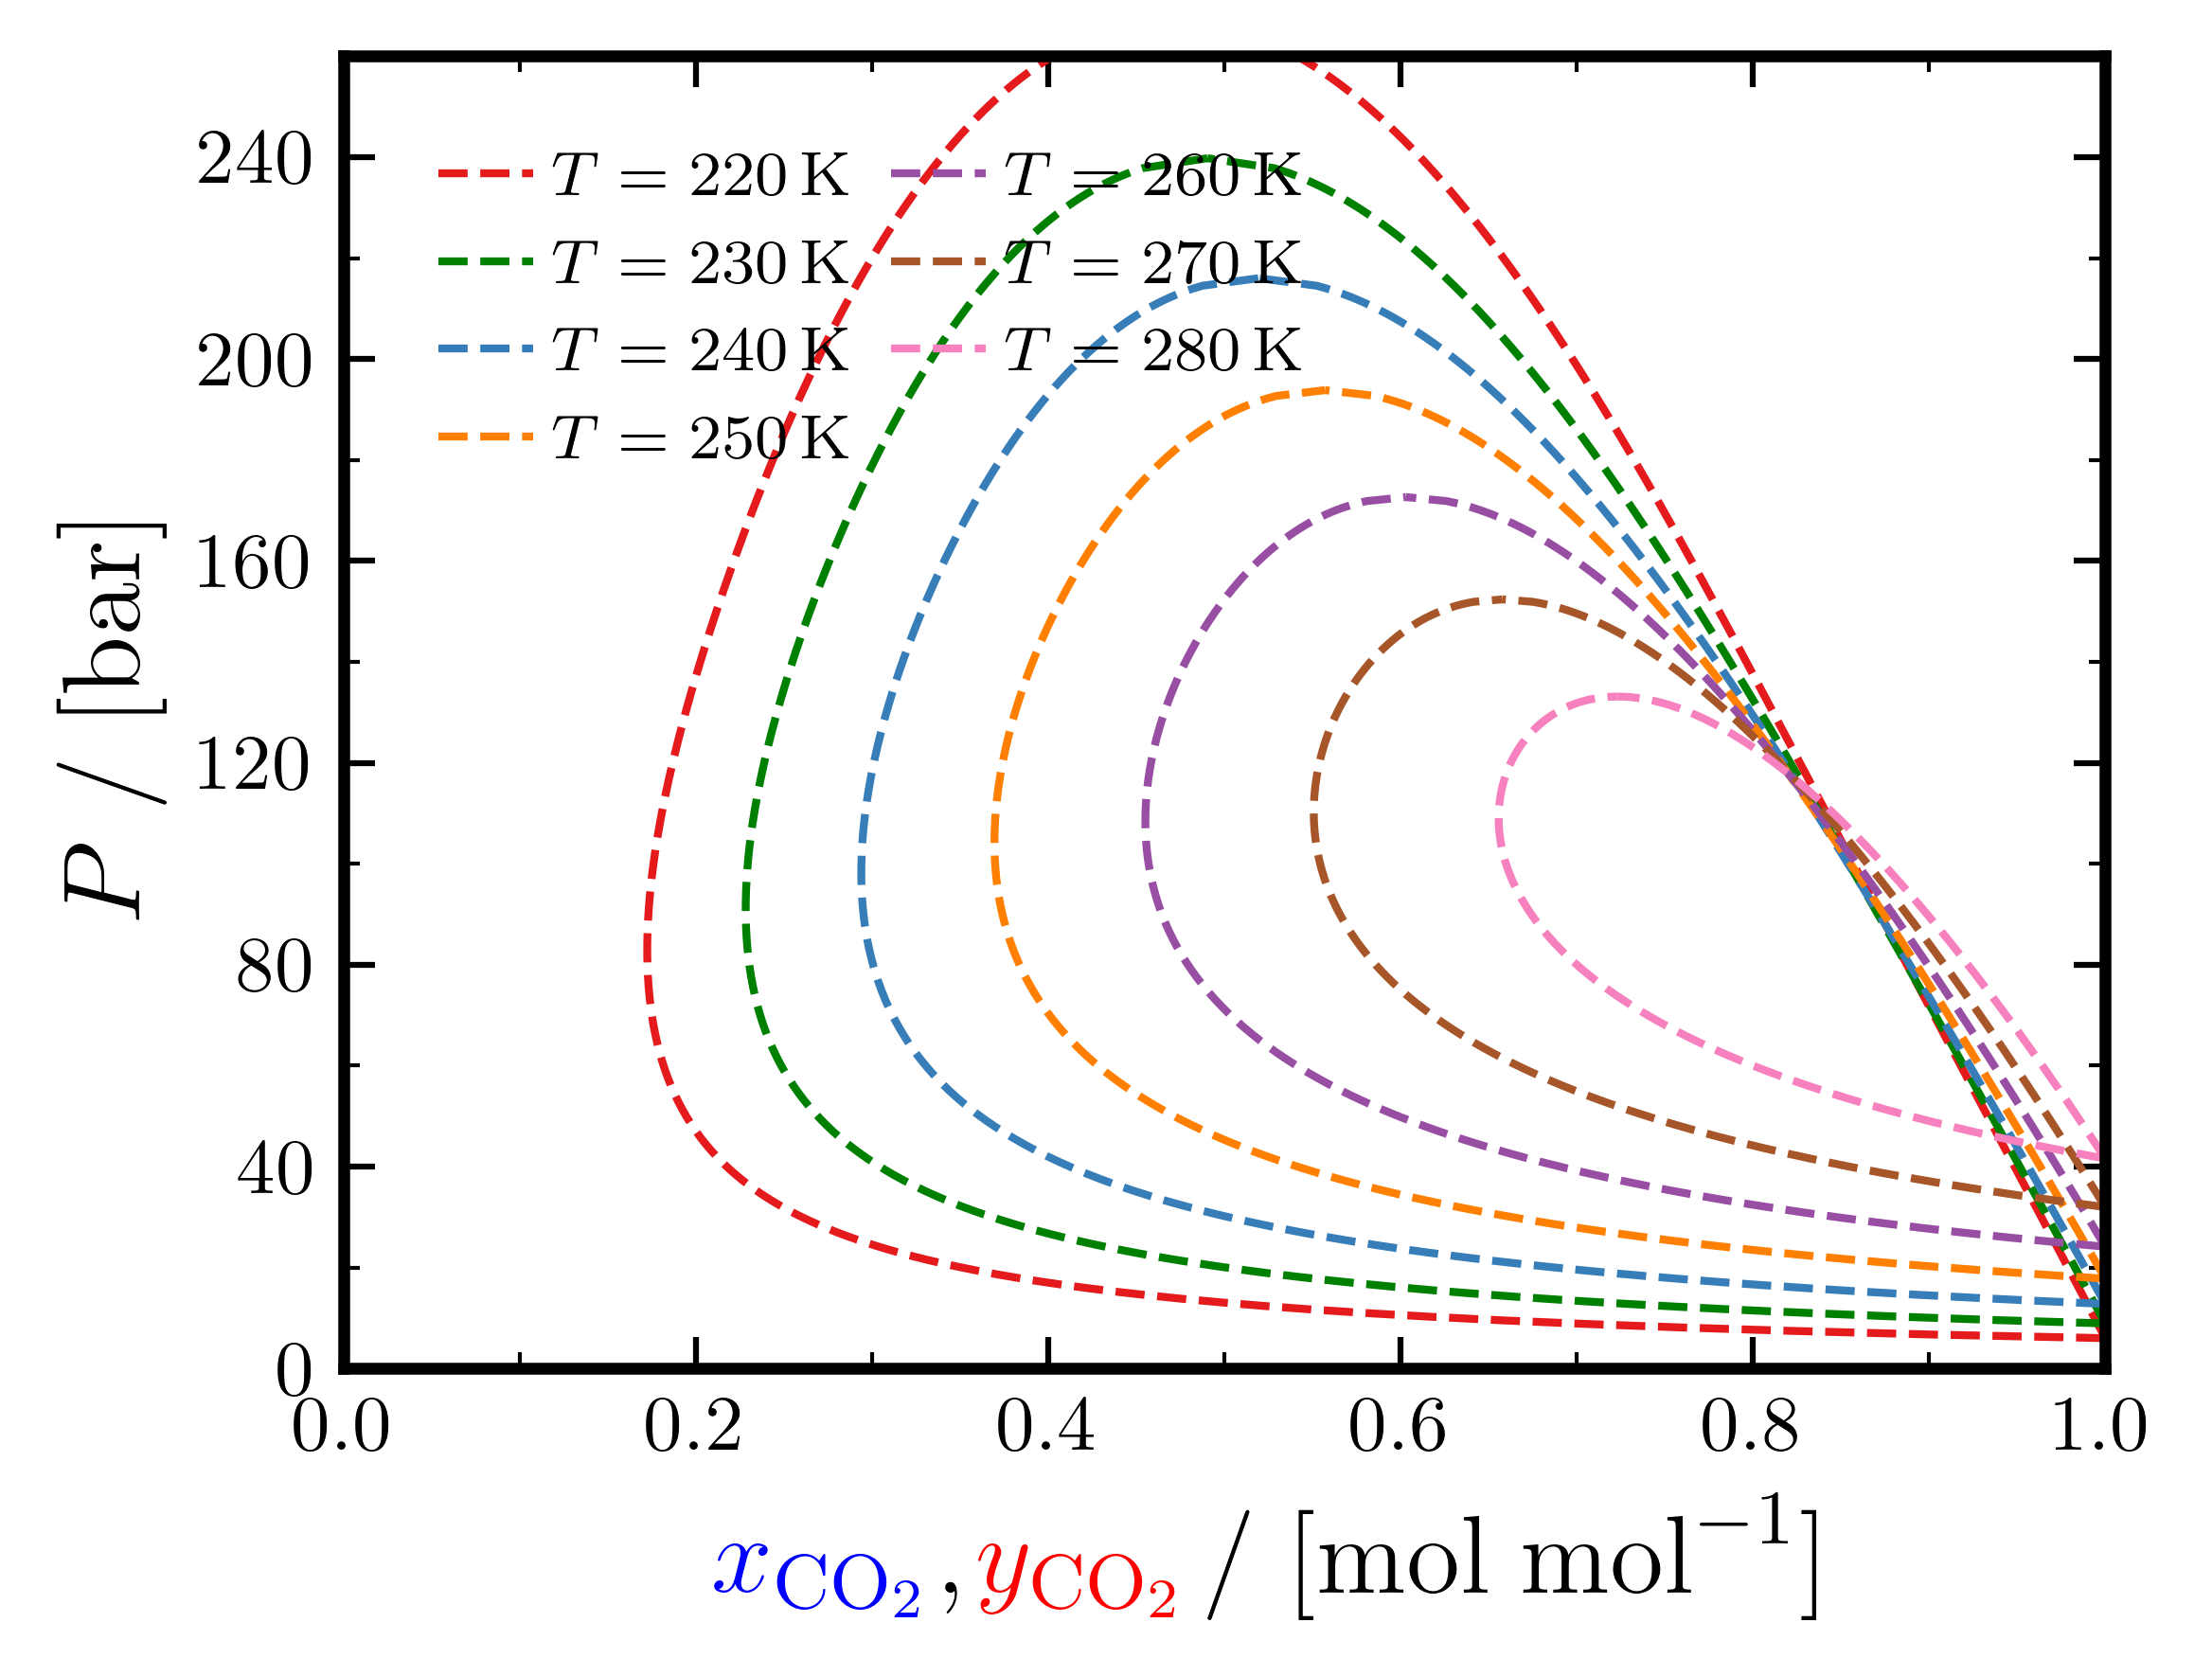

In [6]:
fig1, ax1 = ps.plot_init()

for T, color in zip(temperatures, ps.colors):
    
    kij_T       = 0
    eos         = eos_from_kij_helmholtz(kij_T, parameters)
    dia_kij     = feos.PhaseDiagram.binary_vle(eos,T * si.KELVIN, npoints=pts)
    df_kij      = pd.DataFrame(dia_kij.to_dict(feos.Contributions.Residual))
    
    # Liquid branch
    ax1.plot(df_kij["x1"],df_kij["pressure"] * (si.PASCAL / si.BAR),
        color=color,linestyle="--",linewidth=ps.linewidth,label=fr"$T={T:.0f}\,\mathrm{{K}}$")

    # Vapor branch
    ax1.plot(df_kij["y1"],df_kij["pressure"] * (si.PASCAL / si.BAR),color=color,
        linestyle="--",linewidth=ps.linewidth)
    
ax1.minorticks_on()
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(40))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(20))

set_custom_xlabel(ax1, fontsize=ps.label_fontsize)
ax1.set_ylabel(r'$P \; / \; [\mathrm{bar}]$', fontsize=ps.label_fontsize)
ax1.set_xlabel("")
ax1.set_xlim(0, 1.0)
ax1.set_ylim(0, 260)

ps.style_legend(ax1,loc='upper left',ncol=2,borderaxespad=1.0,frame=False)
plt.show()
save_plot(fig1, f'PX_DIAGRAM_comp_{fluid}_multiT_O')

In [7]:
dfs = []

for T in temperatures:

    kij_T    = kij(T)
    eos      = eos_from_kij_helmholtz(kij_T, parameters)
    dia_kij  = feos.PhaseDiagram.binary_vle(eos, T * si.KELVIN, npoints=pts)
    IFT_kij  = feos.SurfaceTensionDiagram(dia_kij.states, n_grid=100)

    xL_kij  = IFT_kij.liquid.molefracs[:, 1]
    yV_kij  = IFT_kij.vapor.molefracs[:, 1]

    enrichment_kij = np.array(IFT_kij.interfacial_enrichment)
    enrichment_kij_N2 = enrichment_kij[:, 0]

    df_ift_kij = pd.DataFrame({
        "Temperature_[K]": np.full_like(IFT_kij.liquid.pressure / si.BAR, T, dtype=float),
        "Pressure_[bar]": IFT_kij.liquid.pressure / si.BAR,
        "Surface_Tension_[mN/m]": IFT_kij.surface_tension / (si.MILLI * si.NEWTON / si.METER),
        "Interfacial_Thickness_[Å]": IFT_kij.interfacial_thickness / si.ANGSTROM,
        "x_CO2": xL_kij,
        "y_CO2": yV_kij,
        "liquid_density_[kg/m3]": mass_density(IFT_kij.liquid.density, M_mix(xL_kij)),
        "vapor_density_[kg/m3]":  mass_density(IFT_kij.vapor.density,  M_mix(yV_kij)),
        "Enrichment_N2_[-]": enrichment_kij_N2,
    })

    dfs.append(df_ift_kij)

IFT_data_kij = pd.concat(dfs, ignore_index=True)
IFT_data_kij.to_csv("IFT_kij_all_temperatures.csv",index=False)


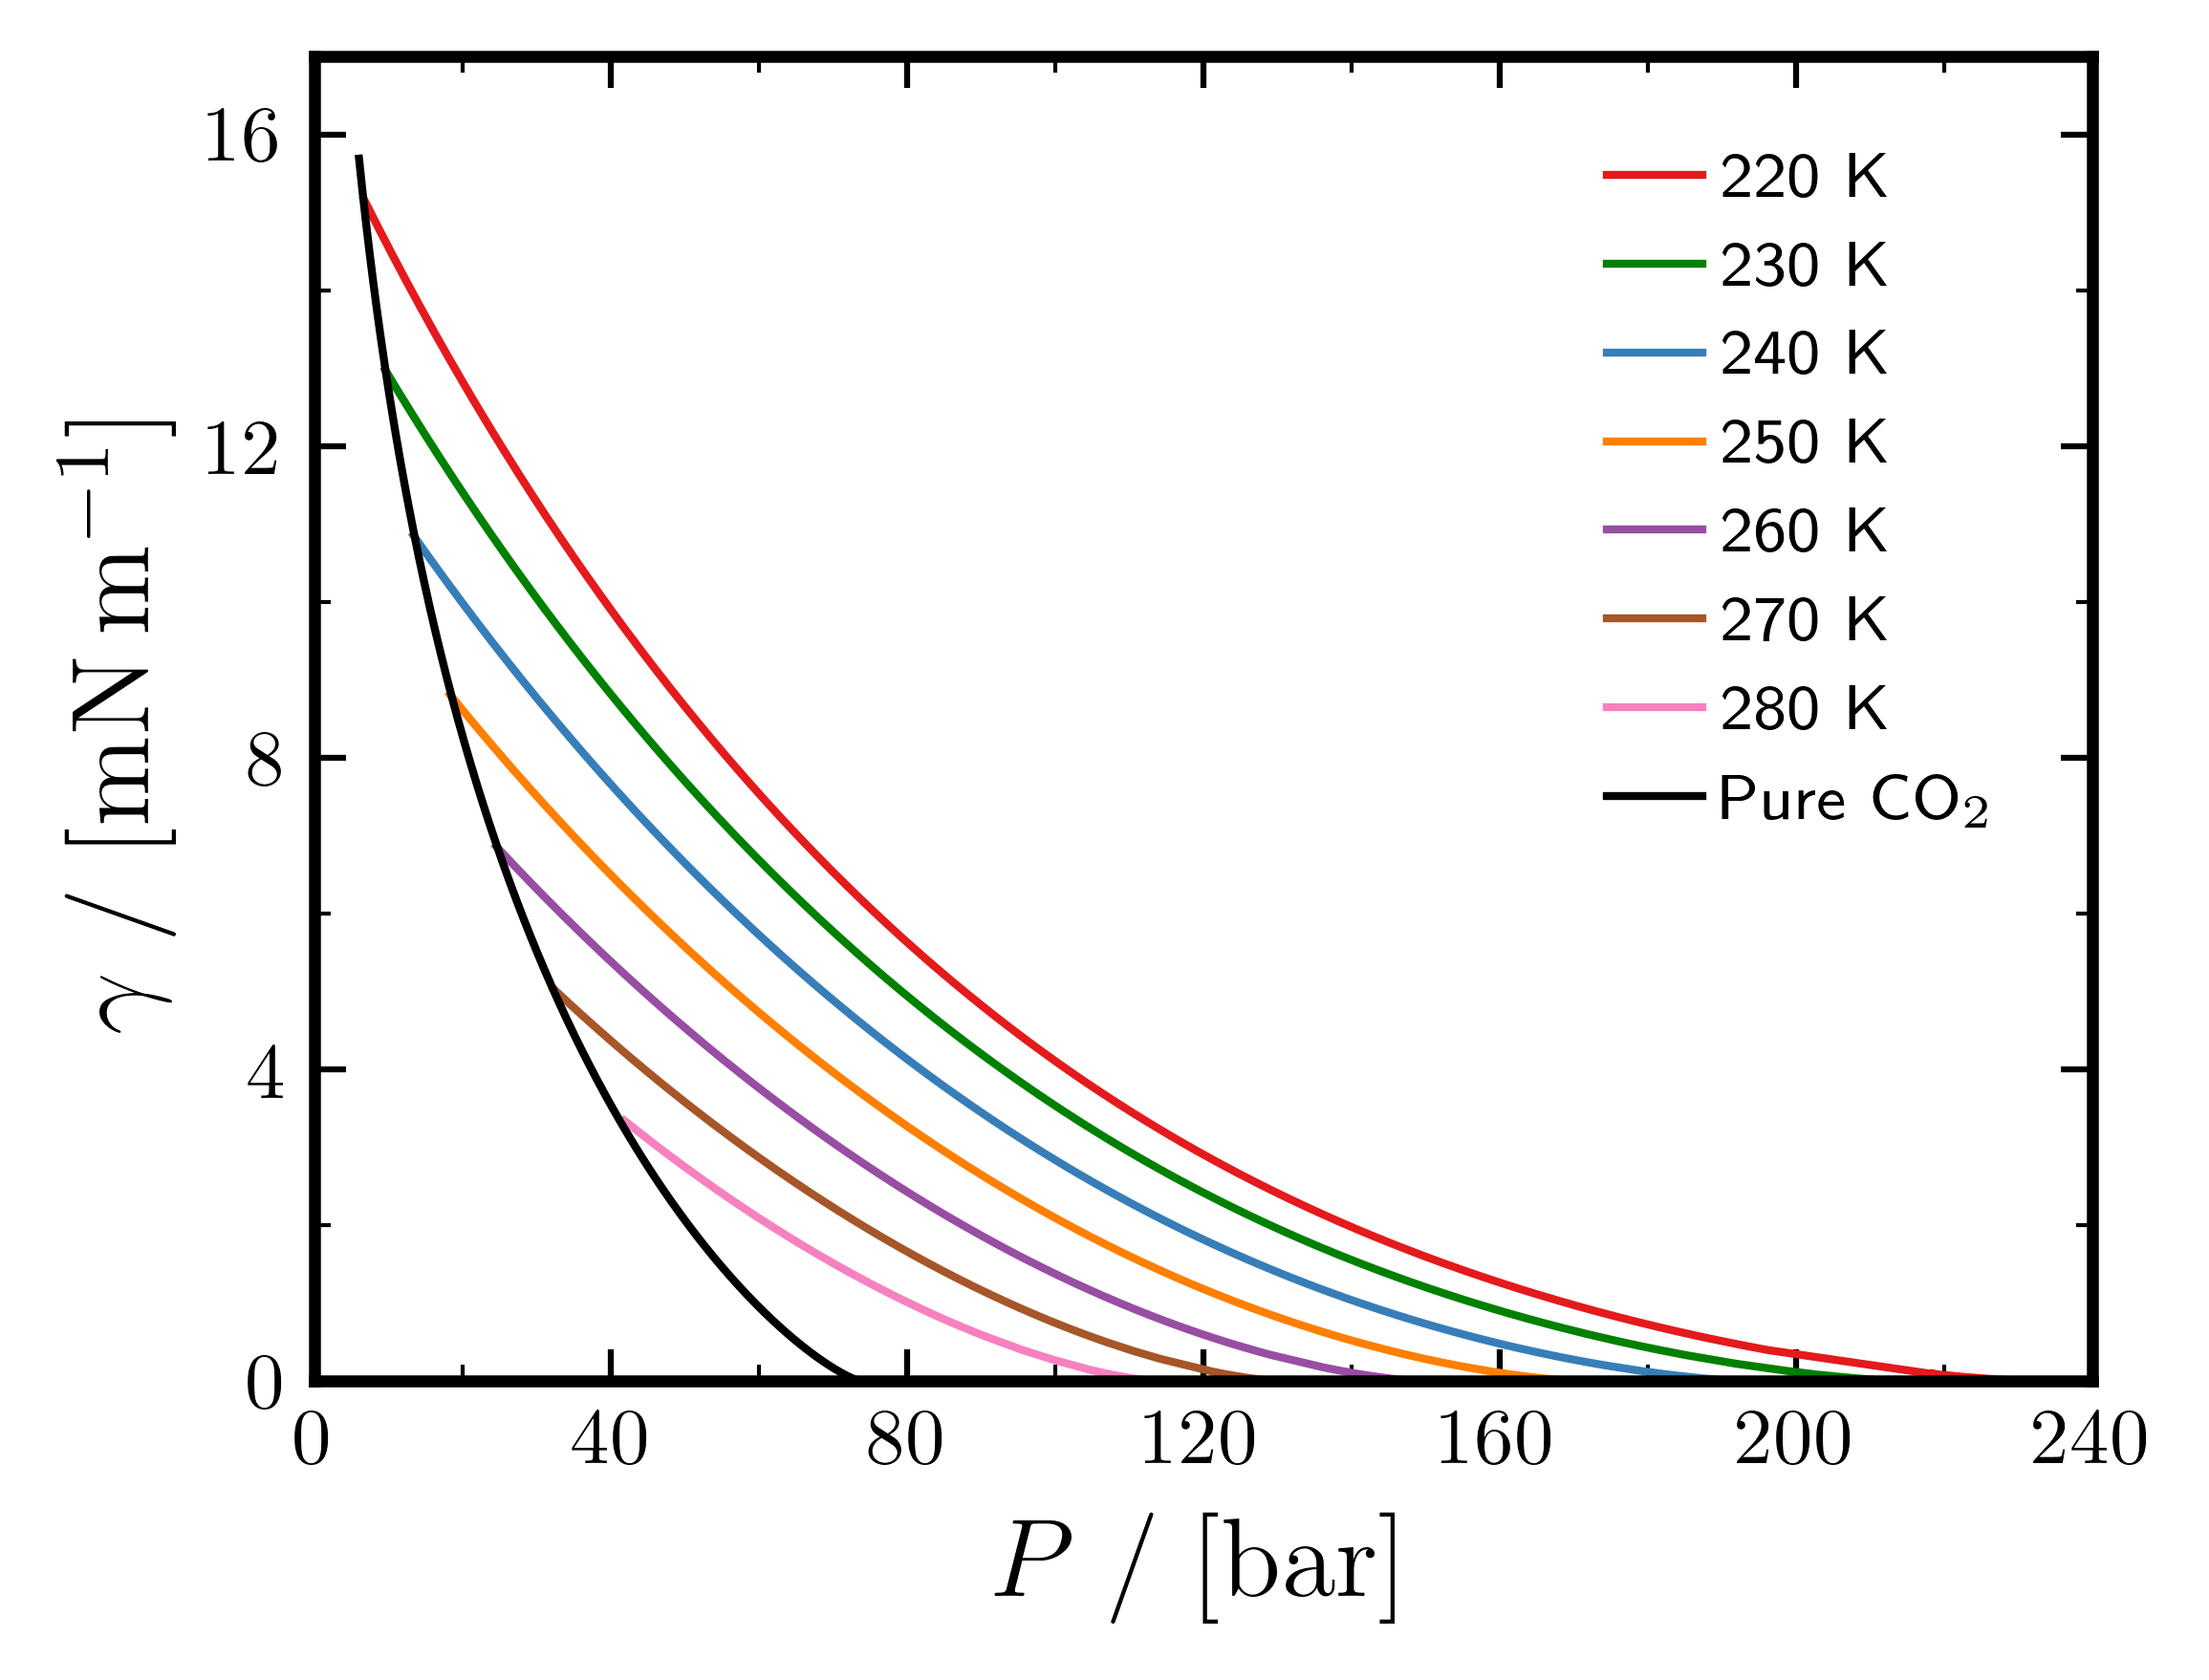

In [8]:
IFT_data_kij = pd.read_csv("IFT_kij_all_temperatures.csv")

fig2, ax2 = ps.plot_init()

for T, color in zip(temperatures, ps.colors):
    sub = IFT_data_kij[IFT_data_kij["Temperature_[K]"] == T]
    plt.plot(sub["Pressure_[bar]"], sub["Surface_Tension_[mN/m]"], color=color, linestyle='-', linewidth=1, label=f"{T} K")
    
ax2.plot(P_RP_Pure_CO2, IFT_RP_Pure_CO2 * 1e3, label=r'Pure CO$_2$', 
         linewidth=ps.linewidth, linestyle='-', color='k')

ax2.minorticks_on()
ax2.xaxis.set_major_locator(ticker.MultipleLocator(40))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(20))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(4))
ax2.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax2.set_xlabel(r'$P \; / \; [\mathrm{bar}]$', fontsize=ps.label_fontsize)
ax2.set_ylabel(r'$\gamma \; / \; [\mathrm{mN\,m^{-1}}]$', fontsize=ps.label_fontsize)

ax2.set_ylim(0,17)
ax2.set_xlim(0,240)

ps.style_legend(ax2,loc='upper right',ncol=1,
    borderaxespad=1.0,frame=False)

plt.show()
save_plot(fig2, f'IFT_vs_Pressure_{fluid}_multiT_Kij')